# 02. 기술통계

| 항목 | 내용 |
|---|---|
| 목적 | 전처리된 카드·기상·유동인구·상가 데이터의 **규모·분포·변동성**을 요약해, EDA에서 무엇을 깊게 볼지 정한다 |
| 입력 | `data/processed/` (01 전처리 산출물) |
| 출력 | 노트북 내 요약표·그림 (가공 데이터 저장 없음) |
| 브랜치 | `ana-stat` |

**진행 순서**
1. 환경 설정·데이터 불러오기
2. 데이터 개요
3. 카드 매출 기술통계 (지역·업종·달력·시간대·고객)
4. 점포당 월매출 — 가설 1의 기초 (업체 규모 차이)
5. 기상 기술통계
6. 기상 유형별 매출 (단순 비교)
7. 유동인구·상가 기술통계
8. 정리 — EDA로 넘길 질문

> 금액은 모두 **신한카드 개인 결제 기준**(분석 포함 업종)이다. 시장 전체 매출이 아니라 그 일부이므로, 절대 금액보다 **비율·상대 비교**로 해석한다.

## 1. 환경 설정·데이터 불러오기

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = ROOT / 'data' / 'processed'
load = lambda name: pd.read_parquet(PROC / f'{name}.parquet')

# ---- 차트 스타일: 얇은 마크, 옅은 격자, 지역 색은 모든 그림에서 고정 (강남 = 파랑, 춘천 = 주황)
INK, INK2, GRID, SURFACE = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
REGION_COLOR = {'강남구': '#2a78d6', '춘천시': '#eb6834'}
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#f0efec', '#9ec5f4', '#3987e5', '#1c5cab', '#0d366b'])
DIV = LinearSegmentedColormap.from_list('div_red_blue', ['#c43a3a', '#e34948', '#f2a3a2', '#f0efec', '#9ec5f4', '#2a78d6', '#1c5cab'])
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.dpi': 110,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK, 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'lines.linewidth': 2,
    'legend.frameon': False, 'legend.fontsize': 9,
})
EOK = 1e8  # 억원

daily = load('analysis_daily_group')       # 날짜 × 지역 × 업종대분류
ind = load('analysis_daily_industry')      # 날짜 × 지역 × 세부 업종
slot = load('analysis_slot_group')         # 날짜 × 시간대 × 지역 × 업종대분류
origin = load('analysis_origin_group')     # 날짜 × 고객출신 × 지역 × 업종대분류
demo = load('analysis_daily_demo')         # 날짜 × 지역 × 성 × 연령대
weather = load('weather_daily')
climate = load('weather_climate')
flow_rm = load('flow_region_month')
flow_dong = load('flow_dong_profile')
store_g = load('store_group_summary')
REGIONS = ['강남구', '춘천시']
print('불러온 테이블:', ', '.join(f'{n}{t.shape}' for n, t in
      [('daily', daily), ('ind', ind), ('slot', slot), ('origin', origin), ('demo', demo), ('weather', weather)]))

불러온 테이블: daily(5520, 51), ind(26128, 52), slot(22080, 63), origin(16560, 52), demo(6624, 52), weather(368, 29)


## 2. 데이터 개요

In [2]:
overview = pd.DataFrame([
    ['카드 일별 × 업종대분류', 'analysis_daily_group', '날짜 × 지역 × 업종대분류(15)', len(daily)],
    ['카드 일별 × 세부 업종', 'analysis_daily_industry', '날짜 × 지역 × 세부 업종(71)', len(ind)],
    ['카드 시간대', 'analysis_slot_group', '날짜 × 6시간 × 지역 × 업종대분류', len(slot)],
    ['카드 고객출신', 'analysis_origin_group', '날짜 × 현지/외지/미상 × 지역 × 업종대분류', len(origin)],
    ['카드 성·연령', 'analysis_daily_demo', '날짜 × 지역 × 성 × 연령대', len(demo)],
    ['기상 일별', 'weather_daily', '날짜 × 지역', len(weather)],
    ['유동인구 행정동', 'flow_dong_profile', '행정동(47) × 6개월 평균', len(flow_dong)],
    ['상가 업종', 'store_group_summary', '지역 × 업종대분류', len(store_g)],
], columns=['내용', '테이블', '단위', '행 수'])
print(f"기간: {daily['date'].min():%Y-%m-%d} ~ {daily['date'].max():%Y-%m-%d} ({daily['date'].nunique()}일), "
      f"휴일 {daily.drop_duplicates('date')['is_offday'].sum()}일 (주말 + 공휴일)")
overview

기간: 2025-07-01 ~ 2025-12-31 (184일), 휴일 59일 (주말 + 공휴일)


,내용,테이블,단위,행 수
0,카드 일별 × 업종대분류,analysis_daily_group,날짜 × 지역 × 업종대분류(15),5520
1,카드 일별 × 세부 업종,analysis_daily_industry,날짜 × 지역 × 세부 업종(71),26128
2,카드 시간대,analysis_slot_group,날짜 × 6시간 × 지역 × 업종대분류,22080
3,카드 고객출신,analysis_origin_group,날짜 × 현지/외지/미상 × 지역 × 업종대분류,16560
4,카드 성·연령,analysis_daily_demo,날짜 × 지역 × 성 × 연령대,6624
5,기상 일별,weather_daily,날짜 × 지역,368
6,유동인구 행정동,flow_dong_profile,행정동(47) × 6개월 평균,47
7,상가 업종,store_group_summary,지역 × 업종대분류,30


## 3. 카드 매출 기술통계
### 3-1. 지역 전체

In [3]:
tot = daily.groupby(['date', 'region'])[['amount', 'count']].sum().reset_index()
reg = tot.groupby('region').agg(총매출=('amount', 'sum'), 총건수=('count', 'sum'),
                                일평균=('amount', 'mean'), 일표준편차=('amount', 'std'),
                                일최소=('amount', 'min'), 일최대=('amount', 'max'))
reg['변동계수(CV)'] = reg['일표준편차'] / reg['일평균']
reg['건당 결제액(원)'] = reg['총매출'] / reg['총건수']
show = reg.copy()
for c in ['총매출', '일평균', '일표준편차', '일최소', '일최대']:
    show[c] = show[c] / EOK
show['총건수'] = show['총건수'] / 1e4
show.rename(columns={'총매출': '총매출(억원)', '총건수': '총건수(만건)', '일평균': '일평균(억원)',
                     '일표준편차': '일표준편차(억원)', '일최소': '일최소(억원)', '일최대': '일최대(억원)'}).round(2)

,총매출(억원),총건수(만건),일평균(억원),일표준편차(억원),일최소(억원),일최대(억원),변동계수(CV),건당 결제액(원)
region,,,,,,,,
강남구,"119,050.59","38,706.85",647.01,111.59,231.95,910.71,0.17,"30,756.98"
춘천시,"15,176.80","4,921.21",82.48,11.26,56.28,118.67,0.14,"30,839.54"


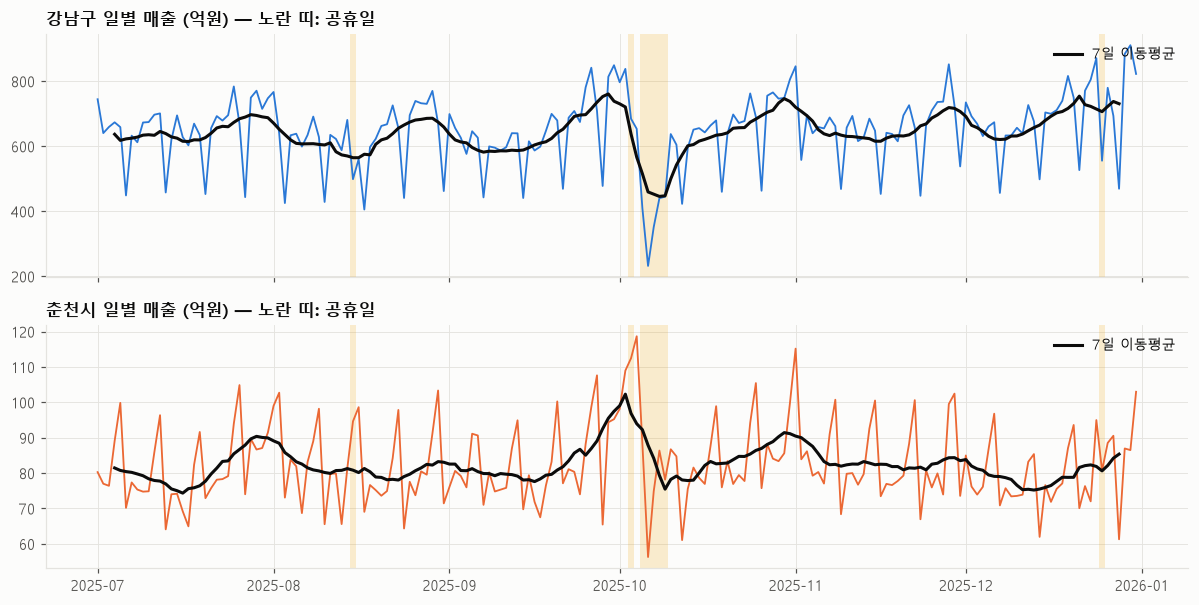

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
for ax, r in zip(axes, REGIONS):
    s = tot[tot['region'] == r].set_index('date')['amount'] / EOK
    ax.plot(s.index, s, color=REGION_COLOR[r], lw=1.2)
    ax.plot(s.index, s.rolling(7, center=True).mean(), color=INK, lw=2, label='7일 이동평균')
    off = daily.drop_duplicates('date').set_index('date')['is_holiday']
    for d in off[off].index:
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color='#eda100', alpha=0.18, lw=0)
    ax.set_title(f'{r} 일별 매출 (억원) — 노란 띠: 공휴일', fontsize=11)
    ax.legend(loc='upper right')
fig.tight_layout()

- 강남구 일평균 매출은 춘천시의 약 **8배**지만, 건당 결제액은 약 3만원으로 거의 같다. 규모 차이는 결제 단가가 아니라 **결제 건수**에서 나온다.
- 일 매출 변동계수는 두 지역 모두 0.14~0.17로 크지 않다. 그래프의 큰 출렁임은 대부분 **주말·추석 연휴**에서 나온다. 날씨 효과는 이 달력 변동 위에 얹힌 작은 신호이므로, 이후 분석에서 달력 통제가 필수다.

### 3-2. 업종대분류별 규모와 변동성
- **비중**: 지역 매출 안에서 차지하는 몫
- **변동계수(CV)** = 일 매출 표준편차 ÷ 평균. 클수록 날마다 매출이 크게 출렁인다 (요일·연휴·날씨 영향을 모두 포함한 값)

In [5]:
g = daily.groupby(['region', 'industry_group'])['amount']
grp = pd.DataFrame({'총매출(억원)': g.sum() / EOK, '일평균(억원)': g.mean() / EOK,
                    '일중앙값(억원)': g.median() / EOK, 'CV': g.std() / g.mean(), '왜도': g.skew()})
grp['지역 내 비중(%)'] = grp['총매출(억원)'] / grp.groupby(level=0)['총매출(억원)'].transform('sum') * 100
grp = grp[['총매출(억원)', '지역 내 비중(%)', '일평균(억원)', '일중앙값(억원)', 'CV', '왜도']]
grp.round(2).sort_values(['region', '총매출(억원)'], ascending=[True, False])

총매출(억원)  지역 내 비중(%)  일평균(억원)  일중앙값(억원)   CV    왜도
region industry_group                                                    
강남구    의료·보건          29,681.47       24.93   161.31    178.76 0.48 -0.55
       대형유통           26,408.98       22.18   143.53    141.72 0.15  1.05
       기타소매           16,872.62       14.17    91.70     90.49 0.12  0.92
       음식점            14,362.79       12.06    78.06     78.49 0.18 -0.21
       교육              9,304.36        7.82    50.57     47.79 0.34  0.60
       의류·잡화           7,218.11        6.06    39.23     37.76 0.24  1.03
       카페·디저트          4,210.19        3.54    22.88     22.58 0.10  0.63
       편의점             2,266.82        1.90    12.32     12.96 0.16 -0.79
       교통·자동차          2,089.16        1.75    11.35     11.77 0.19 -0.40
       미용·개인서비스        1,903.21        1.60    10.34     10.15 0.30  0.26
       여가·오락           1,679.52        1.41     9.13      9.36 0.26 -0.14
       식료품소매           1,230.37        1.03     6.69      6.53 0.30  0.31
       숙박              1,013.18        0.85     5.51      5.14 0.40  1.45
       주점·유흥             412.65        0.35     2.24      2.28 0.42  0.07
       간편식               397.15        0.33     2.16      2.16 0.11 -0.31
춘천시    음식점             3,640.62       23.99    19.79     18.77 0.22  0.83
       대형유통            2,445.94       16.12    13.29     11.92 0.26  1.58
       교통·자동차          2,113.94       13.93    11.49     11.65 0.17  0.02
       의료·보건           1,984.58       13.08    10.79     12.21 0.41 -0.97
       식료품소매             870.34        5.73     4.73      4.38 0.28  2.69
       기타소매              862.81        5.69     4.69      4.54 0.24  0.94
       편의점               828.14        5.46     4.50      4.47 0.08  0.31
       여가·오락             818.52        5.39     4.45      4.58 0.37 -0.06
       의류·잡화             484.88        3.19     2.64      2.52 0.26  1.09
       카페·디저트            303.85        2.00     1.65      1.59 0.17  0.87
       교육                290.83        1.92     1.58      1.55 0.63  1.01
       미용·개인서비스          259.45        1.71     1.41      1.31 0.27  0.73
       간편식               102.78        0.68     0.56      0.54 0.16  0.40
       숙박                 86.71        0.57     0.47      0.37 0.63  1.78
       주점·유흥              83.42        0.55     0.45      0.43 0.38  0.64

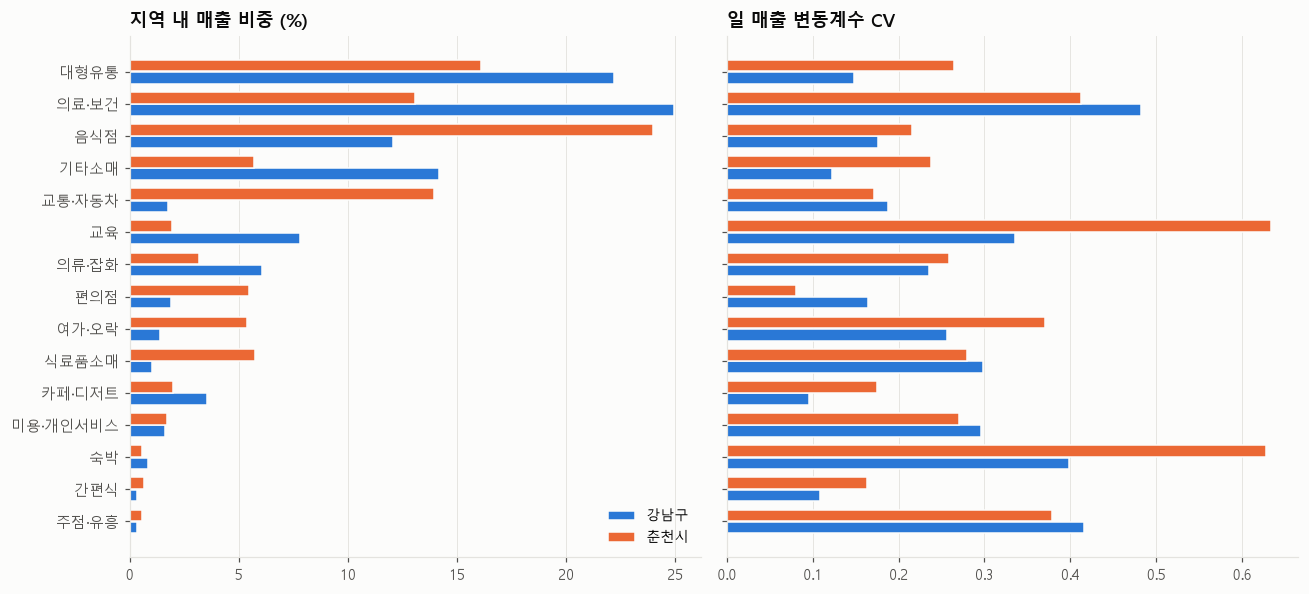

In [6]:
share = grp['지역 내 비중(%)'].unstack(0)
cv = grp['CV'].unstack(0)
order = share.mean(axis=1).sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
y = np.arange(len(order))
for ax, data, title, fmt in [(axes[0], share, '지역 내 매출 비중 (%)', '{:.1f}'), (axes[1], cv, '일 매출 변동계수 CV', '{:.2f}')]:
    for k, r in enumerate(REGIONS):
        ax.barh(y + (k - 0.5) * 0.38, data.loc[order, r], height=0.36, color=REGION_COLOR[r], label=r,
                edgecolor=SURFACE, linewidth=1)
    ax.set_yticks(y, order)
    ax.set_title(title)
    ax.grid(axis='y', visible=False)
axes[0].legend(loc='lower right')
fig.tight_layout()

- **강남은 의료·보건(24.9%)과 대형유통(22.2%)이 매출의 절반**에 가깝다. 대형 병원·백화점 매출이 커서, 지역 합계로 보면 소상공인 업종의 신호가 묻힌다. → 분석은 **업종대분류 단위**로 해야 한다.
- 춘천은 음식점(24.0%), 대형유통(16.1%), 교통·자동차(13.9%) 순이다.
- 변동계수가 큰 업종은 의료·보건(주말 휴진)·교육·숙박·주점·유흥이다. 의료·교육은 요일 구조 때문에, 숙박·주점은 수요 자체의 변동 때문에 출렁인다.

### 3-3. 달력 효과 — 월·요일·공휴일

region      강남구    춘천시
월    7   100.60  98.10
     8    96.00  99.30
     9    99.00  99.50
     10   96.20 104.20
     11  101.20 101.70
     12  107.10  97.20
요일   월   102.50  96.70
     화   105.40  95.10
     수   103.40  95.70
     목   103.00  96.40
     금   110.50 110.40
     토   103.60 120.30
     일    71.10  85.80
일 유형 공휴일  69.90 101.80
     주말   87.90 103.00
     평일  106.90  98.70

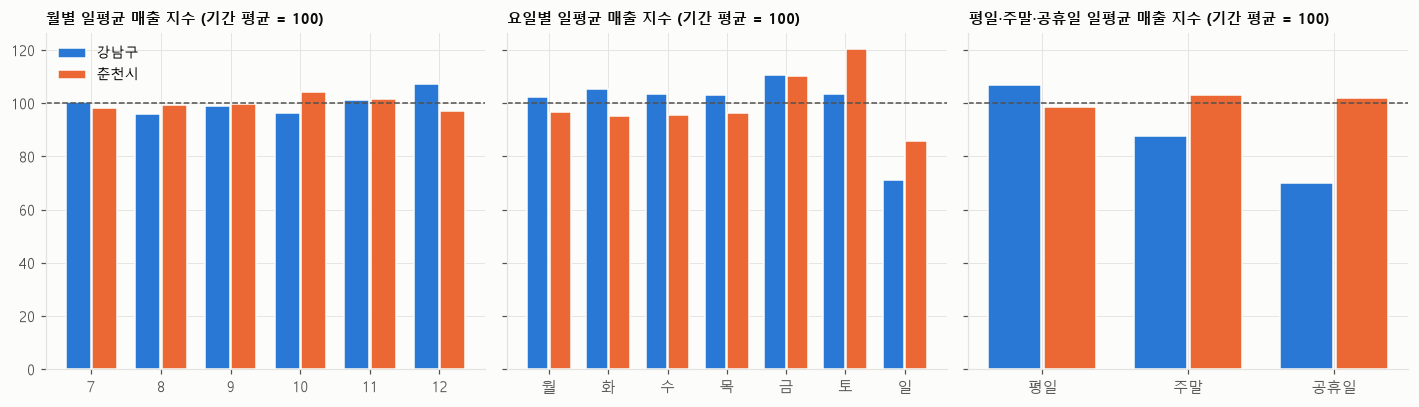

In [7]:
def index_by(col):
    t = tot.merge(daily.drop_duplicates('date')[['date', col]], on='date')
    m = t.groupby(['region', col], observed=True)['amount'].mean()
    return (m / t.groupby('region')['amount'].mean() * 100).unstack(0)

month_idx, dow_idx = index_by('month'), index_by('dow')
hol = tot.merge(daily.drop_duplicates('date')[['date', 'is_holiday', 'is_weekend']], on='date')
hol['일 유형'] = np.select([hol['is_holiday'], hol['is_weekend']], ['공휴일', '주말'], '평일')
hol_idx = (hol.groupby(['region', '일 유형'])['amount'].mean() / hol.groupby('region')['amount'].mean() * 100).unstack(0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, data, title in [(axes[0], month_idx, '월별'), (axes[1], dow_idx, '요일별'), (axes[2], hol_idx.loc[['평일', '주말', '공휴일']], '평일·주말·공휴일')]:
    x = np.arange(len(data))
    for k, r in enumerate(REGIONS):
        ax.bar(x + (k - 0.5) * 0.38, data[r], width=0.36, color=REGION_COLOR[r], label=r, edgecolor=SURFACE)
    ax.axhline(100, color=INK2, lw=1, ls='--')
    ax.set_xticks(x, data.index)
    ax.set_title(f'{title} 일평균 매출 지수 (기간 평균 = 100)', fontsize=10)
axes[0].legend()
fig.tight_layout()
pd.concat({'월': month_idx, '요일': dow_idx, '일 유형': hol_idx}).round(1)

- **두 지역의 요일 패턴이 반대**다. 강남은 평일 매출이 높고 일요일·공휴일이 70% 수준으로 떨어지는 **직장인 상권**이다. 춘천은 토요일이 가장 높고 공휴일도 평소 수준을 유지하는 **주말·방문객 상권**이다.
- 따라서 같은 날씨라도 **평일에 오는 비와 주말에 오는 비의 피해가 지역마다 다를 수 있다** (EDA에서 확인).

### 3-4. 시간대별 매출 비중

지역 전체 시간대 비중(%)


time_slot,00_05,06_11,12_17,18_23
region,,,,
강남구,3.80,22.30,48.50,25.40
춘천시,2.10,20.80,50.00,27.10


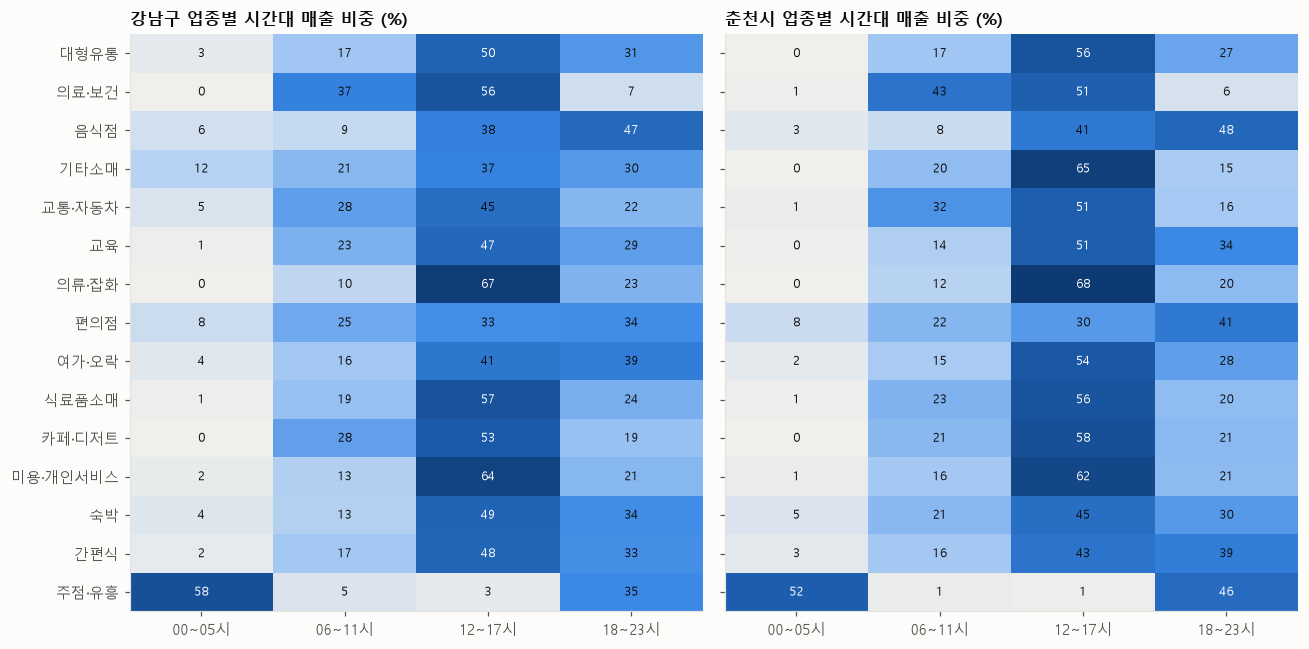

In [8]:
sl = slot.groupby(['region', 'industry_group', 'time_slot'], observed=True)['amount'].sum()
sl_share = (sl / sl.groupby(level=[0, 1]).transform('sum') * 100).unstack('time_slot')
total_slot = slot.groupby(['region', 'time_slot'], observed=True)['amount'].sum()
print('지역 전체 시간대 비중(%)')
display((total_slot / total_slot.groupby(level=0).transform('sum') * 100).unstack().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ax, r in zip(axes, REGIONS):
    m = sl_share.loc[r].loc[order[::-1]]
    im = ax.imshow(m.values, cmap=SEQ, vmin=0, vmax=70, aspect='auto')
    ax.set_xticks(range(4), ['00~05시', '06~11시', '12~17시', '18~23시'])
    ax.set_yticks(range(len(m)), m.index)
    ax.grid(False)
    for i in range(m.shape[0]):
        for j in range(4):
            v = m.values[i, j]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8, color='white' if v > 45 else INK)
    ax.set_title(f'{r} 업종별 시간대 매출 비중 (%)', fontsize=11)
fig.tight_layout()

- 매출의 절반이 낮 시간(12~17시)에 몰리고, 새벽(00~05시) 비중은 2~4%다.
- 업종별 시간 구조가 뚜렷하다: **주점·유흥은 자정 이후(00~05시) 52~58%**, 음식점은 저녁(18~23시) 47~48%, 의료·보건(37~43%)·교통·자동차(28~32%)는 오전 비중이 높다.
- 같은 하루 강수량이라도 **비가 온 시간대**에 따라 업종별 피해가 다를 수 있다 (예: 저녁 비 → 음식점·주점). EDA에서 시간대 기상과 함께 본다.

### 3-5. 고객 구성 — 성·연령, 현지·외지

In [9]:
dm = demo.groupby(['region', 'sex', 'age'])['amount'].sum()
dm_share = (dm / dm.groupby(level=0).transform('sum') * 100).unstack('sex')
dm_share.columns = ['여성(%)', '남성(%)']
age_share = dm_share.sum(axis=1).unstack(0)
print('연령대별 매출 비중(%) — 남녀 합')
display(age_share.round(1).T)

og = origin.groupby(['region', 'industry_group', 'customer_origin'], observed=True)['amount'].sum()
og_share = (og / og.groupby(level=[0, 1]).transform('sum') * 100).unstack('customer_origin')
og_tot = origin.groupby(['region', 'customer_origin'], observed=True)['amount'].sum()
print('고객 출신별 매출 비중(%) — 지역 전체 (현지 = 가맹점과 같은 시도 거주)')
display((og_tot / og_tot.groupby(level=0).transform('sum') * 100).unstack().round(1))
print('업종별 외지 고객 매출 비중(%)')
og_share['외지'].unstack(0).round(1).sort_values('춘천시', ascending=False)

연령대별 매출 비중(%) — 남녀 합


age,10,20,30,40,50,60,70,80,90
region,,,,,,,,,
강남구,0.40,9.30,23.20,29.90,22.40,9.90,3.70,1.00,0.10
춘천시,0.50,9.10,19.20,23.50,25.20,16.20,5.20,1.10,0.10


고객 출신별 매출 비중(%) — 지역 전체 (현지 = 가맹점과 같은 시도 거주)


customer_origin,미상,외지,현지
region,,,
강남구,0.10,49.50,50.40
춘천시,0.10,17.90,82.00


업종별 외지 고객 매출 비중(%)


region,강남구,춘천시
industry_group,,
숙박,36.10,76.30
여가·오락,22.50,60.00
음식점,34.00,24.30
편의점,29.80,18.40
식료품소매,27.00,17.70
카페·디저트,57.30,17.20
간편식,31.90,14.40
주점·유흥,31.60,13.80
의류·잡화,42.30,12.50


- 연령: 강남은 30~40대, **춘천은 50~60대 이상 비중이 높다** (60대 이상 22.6% vs 14.7%).
- 고객 출신: **강남 매출의 절반이 다른 시도 거주자**(출퇴근·방문)인데, 춘천은 82%가 강원 거주자다.
- 그런데 춘천의 **숙박(76%)·여가·오락(60%)은 외지 고객 의존도가 매우 높다.** 날씨가 나빠 방문객이 오지 않으면 이 업종들이 먼저 타격을 받을 수 있다 → EDA에서 고객 출신별 날씨 반응을 비교한다.

## 4. 점포당 월매출 — 가설 1의 기초

가설 1은 "같은 100만원 피해라도 월매출이 100만·500만·1,000만원인 업체에게 주는 타격이 다르다"이다.
카드 데이터는 업종 합계라 개별 점포 매출이 없으므로, **업종대분류 월매출 ÷ 상가정보 점포 수**로 '평균적인 점포 하나'의 규모를 근사한다.

- 신한카드 개인 결제만 반영된 값이라 실제 매출보다 작다. 업종 간 **상대적 규모 차이**를 보는 용도다.
- 상가정보(2026.6)와 카드(2025 하반기)의 시점 차이가 있다.

n_stores           월매출(억원)        점포당 월매출(만원)          
region              강남구      춘천시      강남구    춘천시         강남구       춘천시
industry_group                                                        
간편식            1,474.00   836.00    66.20  17.10      449.10    204.90
교육             5,164.00 1,218.00 1,550.70  48.50    3,003.00    398.00
교통·자동차           474.00   514.00   348.20 352.30    7,345.80  6,854.50
기타소매           3,122.00 1,362.00 2,812.10 143.80    9,007.40  1,055.80
대형유통             452.00   407.00 4,401.50 407.70   97,378.20 10,016.10
미용·개인서비스       3,629.00 1,537.00   317.20  43.20      874.10    281.30
숙박               537.00   818.00   168.90  14.50    3,144.60    176.70
식료품소매            863.00   490.00   205.10 145.10    2,376.10  2,960.30
여가·오락          1,384.00   688.00   279.90 136.40    2,022.50  1,982.80
음식점            7,256.00 3,333.00 2,393.80 606.80    3,299.10  1,820.50
의료·보건          3,825.00   579.00 4,946.90 330.80   12,933.10  5,712.70
의류·잡화          3,499.00 1,033.00 1,203.00  80.80    3,438.20    782.30
주점·유흥          1,227.00   610.00    68.80  13.90      560.50    227.90
카페·디저트         2,671.00 1,128.00   701.70  50.60    2,627.10    449.00
편의점              803.00   373.00   377.80 138.00    4,704.90  3,700.30

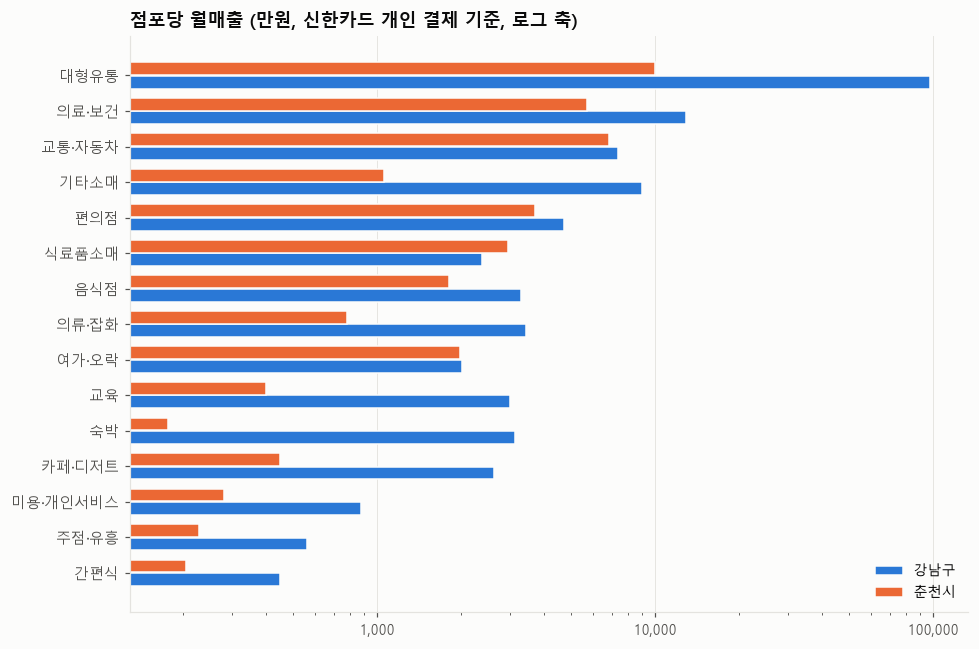

In [10]:
monthly = daily.groupby(['region', 'industry_group', 'month'])['amount'].sum().reset_index()
per_store = (monthly.groupby(['region', 'industry_group'])['amount'].mean().rename('월매출').reset_index()
             .merge(store_g, on=['region', 'industry_group']))
per_store['점포당 월매출(만원)'] = per_store['월매출'] / per_store['n_stores'] / 1e4
per_store['월매출(억원)'] = per_store['월매출'] / EOK
ps = per_store.pivot(index='industry_group', columns='region', values='점포당 월매출(만원)')
ps = ps.loc[ps.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(ps))
for k, r in enumerate(REGIONS):
    ax.barh(y + (k - 0.5) * 0.38, ps[r], height=0.36, color=REGION_COLOR[r], label=r, edgecolor=SURFACE)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_yticks(y, ps.index)
ax.grid(axis='y', visible=False)
ax.set_title('점포당 월매출 (만원, 신한카드 개인 결제 기준, 로그 축)')
ax.legend(loc='lower right')
fig.tight_layout()
per_store.pivot(index='industry_group', columns='region', values=['n_stores', '월매출(억원)', '점포당 월매출(만원)']).round(1)

In [11]:
print('점포당 월매출 분포 (지역 × 업종대분류 30개 단위, 만원)')
display(per_store['점포당 월매출(만원)'].describe(percentiles=[.1, .25, .5, .75, .9]).to_frame().T.round(0))
r = per_store['점포당 월매출(만원)']
print(f'가장 큰 단위 ÷ 가장 작은 단위 = {r.max() / r.min():.0f}배')

# 같은 100만원 손실이 점포 월매출에서 차지하는 비율
loss = 100  # 만원
per_store['100만원 손실 = 월매출의 %'] = loss / per_store['점포당 월매출(만원)'] * 100
per_store.sort_values('점포당 월매출(만원)')[['region', 'industry_group', '점포당 월매출(만원)', '100만원 손실 = 월매출의 %']].round(1)

점포당 월매출 분포 (지역 × 업종대분류 30개 단위, 만원)


,count,mean,std,min,10%,25%,50%,75%,90%,max
점포당 월매출(만원),30.00,"6,326.00","17,497.00",177.00,276.00,616.00,"2,502.00","4,454.00","9,108.00","97,378.00"


가장 큰 단위 ÷ 가장 작은 단위 = 551배


,region,industry_group,점포당 월매출(만원),100만원 손실 = 월매출의 %
21,춘천시,숙박,176.70,56.60
15,춘천시,간편식,204.90,48.80
27,춘천시,주점·유흥,227.90,43.90
20,춘천시,미용·개인서비스,281.30,35.50
16,춘천시,교육,398.00,25.10
28,춘천시,카페·디저트,449.00,22.30
0,강남구,간편식,449.10,22.30
12,강남구,주점·유흥,560.50,17.80
26,춘천시,의류·잡화,782.30,12.80
5,강남구,미용·개인서비스,874.10,11.40


**가설 1과의 연결**
- 같은 업종대분류 안에서도 지역에 따라, 업종에 따라 '평균 점포 하나'의 월매출 규모는 **최대 550배** 차이가 난다 (신한카드 기준).
- 같은 **100만원 손실**이 춘천 숙박·간편식·주점에서는 점포 월매출의 **44~57%**에 해당하지만, 강남 의료·보건·대형유통에서는 **1% 미만**이다.
- 즉 피해 '금액'만 보면 대형 업종이 크게 보이지만, 업체가 느끼는 '타격'은 **피해액 ÷ 매출(피해율)**로 봐야 한다는 가설 1의 문제의식이 데이터 규모 구조에서도 확인된다.
- 다만 이 값은 신한카드 개인 결제만의 매출이고 점포 수는 2026년 기준이라, **절대 금액이 아닌 업종 간 상대 순서**로만 쓴다. 피해율 자체는 피해 예측 단계에서 계산한다.

## 5. 기상 기술통계
### 5-1. 월별 기상 요약

In [12]:
w = weather.assign(month=weather['date'].dt.month)
wm = w.groupby(['region', 'month']).agg(
    평균기온=('temp_mean', 'mean'), 최고기온_최대=('temp_max', 'max'), 최저기온_최소=('temp_min', 'min'),
    체감최고_평균=('feels_like_max', 'mean'), 강수합=('rain_sum', 'sum'), 강수일=('rain_day', 'sum'),
    강한비일=('heavy_rain_day', 'sum'), 폭염일=('heat_day', 'sum'), 한파일=('cold_day', 'sum'), 눈온날=('snow_day', 'sum'))
wm.round(1)

평균기온  최고기온_최대  최저기온_최소  체감최고_평균    강수합  강수일  강한비일  폭염일  한파일  눈온날
region month                                                                  
강남구    7     28.70    37.60    21.50    32.60 293.90    8     3   15    0    0
       8     28.20    36.20    21.00    32.30 290.30   11     2   10    0    0
       9     23.50    32.50    16.60    27.60 370.70   11     7    0    0    0
       10    16.50    27.70     3.10    20.30 186.20    9     1    0    0    0
       11     9.00    19.90    -2.00    13.70  20.90    3     0    0    0    0
       12     1.30    13.30   -11.80     3.50  41.20    5     0    0    0    2
춘천시    7     27.00    36.90    19.80    31.90 286.00    9     3   12    0    0
       8     26.80    35.20    19.00    31.90 252.90    9     4    7    0    0
       9     21.60    32.70    13.00    26.90 381.40   12     7    0    0    0
       10    15.20    27.30    -2.60    19.90 157.20    9     3    0    0    0
       11     6.30    19.30    -6.20    13.50  19.80    3     0    0    0    0
       12    -0.80    12.40   -13.30     3.10  30.10    4     0    0    3    3

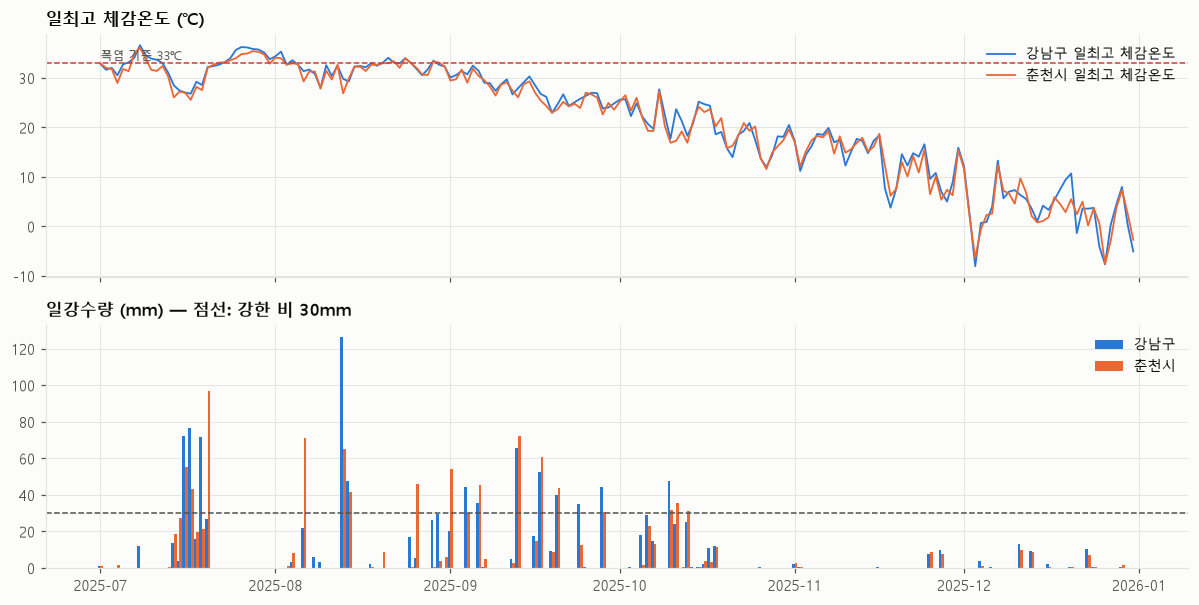

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
for r in REGIONS:
    s = weather[weather['region'] == r].set_index('date')
    axes[0].plot(s.index, s['feels_like_max'], color=REGION_COLOR[r], lw=1.2, label=f'{r} 일최고 체감온도')
    axes[1].bar(s.index + pd.Timedelta(hours=-6 if r == '강남구' else 6), s['rain_sum'], width=0.5,
                color=REGION_COLOR[r], label=r)
axes[0].axhline(33, color='#d03b3b', lw=1, ls='--')
axes[0].text(weather['date'].min(), 33.6, '폭염 기준 33℃', color=INK2, fontsize=8)
axes[0].set_title('일최고 체감온도 (℃)', fontsize=11)
axes[1].axhline(30, color=INK2, lw=1, ls='--')
axes[1].set_title('일강수량 (mm) — 점선: 강한 비 30mm', fontsize=11)
axes[0].legend(loc='upper right'); axes[1].legend(loc='upper right')
fig.tight_layout()

- 7~8월 폭염(강남 25일·춘천 19일), 9월 강한 비 집중(각 7일), 12월 눈·한파로, **여름과 겨울의 극한기상이 한 기간 안에 모두 있다.**
- 9~10월 강수량은 평년의 약 3배로 많았다.

### 5-2. 기상 변수 분포와 구간별 일수

In [14]:
cols = ['temp_mean', 'temp_max', 'temp_min', 'feels_like_max', 'humidity_mean', 'wind_mean', 'rain_sum', 'snow_new']
display(weather.groupby('region')[cols].agg(['mean', 'std', 'min', 'median', 'max']).T.unstack(0).round(1))
print('체감온도 구간별 일수')
display(pd.crosstab(weather['heat_bin'], weather['region']))
print('강수 구간별 일수')
pd.crosstab(weather['rain_bin'], weather['region'])

region       강남구                                                                                  춘천시                                                                           
       temp_mean temp_max temp_min feels_like_max humidity_mean wind_mean rain_sum snow_new temp_mean temp_max temp_min feels_like_max humidity_mean wind_mean rain_sum snow_new
mean       17.90    21.80    14.50          21.70         70.10      2.20     6.50     0.00     16.00    21.30    11.80          21.20         75.80      1.30     6.10     0.10
std        10.60    10.50    11.10          11.10         12.90      0.60    16.90     0.40     10.90    10.80    11.50          11.00         11.40      0.50    15.80     0.50
min        -8.30    -4.00   -11.80          -8.00         38.00      1.30     0.00     0.00     -8.70    -3.80   -13.30          -7.60         32.70      0.40     0.00     0.00
median     20.80    24.10    17.60          24.80         72.20      2.10     0.00     0.00     19.20    23.30    15.80          24.10         77.10      1.30     0.00     0.00
max        32.70    37.60    29.40          36.60         97.50      3.90   126.70     5.10     30.00    36.90    25.90          36.10         95.10      3.20    96.90     6.40

체감온도 구간별 일수


region,강남구,춘천시
heat_bin,,
~30,124,131
30~33,35,34
33~35,17,16
35~,8,3


강수 구간별 일수


region,강남구,춘천시
rain_bin,,
없음,117,123
약(0~5),29,25
보통(5~30),25,20
강(30~80),12,15
극한(80~),1,1


- 강수량은 대부분 0이고 일부 날에 몰린다 (중앙값 0, 최대 127mm). 그래서 강수는 **구간(없음·약·보통·강)으로 나눠** 분석하는 것이 안정적이다.
- 체감 35℃ 이상(강남 8일·춘천 3일), 강수 80mm 이상(각 1일) 구간은 표본이 너무 적다 → 분석에서는 **33℃ 이상, 30mm 이상으로 합친다.**

### 5-3. 2025년 하반기 vs 과거 10년 — 이 기간은 평범했나
연간 극한기상 일수(2015~2024 평균)와 비교한다. 2025년 값은 7~12월만 있으므로, 같은 기간(7~12월)의 과거 평균과 비교해야 공정하다.

In [15]:
from_daily = load('weather_daily')
cmp = from_daily.groupby('region')[['heat_day', 'heavy_rain_day', 'cold_day', 'snow_day']].sum()
cmp.columns = ['폭염일(체감)', '강한비일', '한파일', '눈온날']
past = climate.groupby('region')[['heat_days', 'heavy_rain_days', 'cold_days', 'snow_days']].mean()
past.columns = ['폭염일(기온 33℃, 연)', '강한비일(연)', '한파일(연)', '눈온날(연)']
pd.concat({'2025년 7~12월': cmp, '2015~2024 연평균': past}, axis=1).round(1)

2025년 7~12월               2015~2024 연평균                      
           폭염일(체감) 강한비일 한파일 눈온날 폭염일(기온 33℃, 연) 강한비일(연) 한파일(연) 눈온날(연)
region                                                              
강남구             25   13   0   2          17.90   13.00   4.40   7.60
춘천시             19   17   3   3          19.00   12.00  16.80   3.70

> 2025년 폭염일은 **체감온도** 기준이고, 과거 값은 일자료에 시간별 습도가 없어 **기온** 33℃ 기준이다. 체감온도 기준이 더 넓게 잡히므로 직접 비교하지 않고 순서만 참고한다.

- 강한 비 일수는 과거 연평균과 비슷하지만, 그 일수가 **6개월(그중 7~10월)에 몰려** 있었다.
- 2025년 12월은 한파가 약했다 (강남 0일, 춘천 3일 vs 춘천 연평균 16.8일). 겨울 기상 표본이 적다는 점을 감안해야 한다.

## 6. 기상 유형별 매출 (단순 비교)

기상 유형은 계절에 몰려 있다 (폭염 = 7~8월, 눈 = 12월). 그냥 평균을 비교하면 **계절·요일 효과가 섞인다.**
그래서 기술통계 단계에서는 가장 단순한 통제만 한다:

> **매출 지수** = 그날 매출 ÷ (같은 지역·업종·**월**·**평일/휴일** 의 '평상' 날 평균 매출) × 100

100보다 작으면 같은 달 같은 날 유형의 평범한 날보다 매출이 낮았다는 뜻이다. 휴가철·연휴 같은 다른 요인은 아직 남아 있으므로 **방향을 보는 참고값**이고, 엄밀한 효과 추정은 EDA·피해 예측 단계에서 한다.

In [16]:
base = (daily[daily['weather_type'] == '평상']
        .groupby(['region', 'industry_group', 'month', 'is_offday'])['amount'].mean().rename('base'))
dd = daily.join(base, on=['region', 'industry_group', 'month', 'is_offday'])
dd['sales_index'] = dd['amount'] / dd['base'] * 100

days_n = weather.groupby(['region', 'weather_type'], observed=True).size().unstack()
print('기상 유형별 일수')
display(days_n)

tot_idx = (dd.groupby(['date', 'region', 'weather_type'], observed=True)[['amount', 'base']].sum()
             .assign(idx=lambda x: x['amount'] / x['base'] * 100).reset_index())
print('지역 전체 매출 지수 (일 평균, 평상 = 100 근처)')
tot_idx.groupby(['region', 'weather_type'], observed=True)['idx'].agg(['mean', 'median', 'count']).unstack(0).round(1)

기상 유형별 일수


weather_type,눈,강한 비,폭염,한파,비,평상
region,,,,,,
강남구,2.00,13.00,25.00,NaN,27.00,117.00
춘천시,3.00,17.00,19.00,2.00,26.00,117.00


지역 전체 매출 지수 (일 평균, 평상 = 100 근처)


mean        median         count       
region          강남구    춘천시    강남구    춘천시    강남구    춘천시
weather_type                                          
눈            100.90  98.20 100.90  94.00   2.00   3.00
강한 비         100.50  92.70  92.70  91.10  13.00  17.00
폭염           102.40 104.70 102.60 105.20  25.00  19.00
한파              NaN 113.90    NaN 113.90    NaN   2.00
비             98.60  96.00  98.80  92.40  27.00  26.00
평상           100.00 100.00  96.80  96.70 117.00 117.00

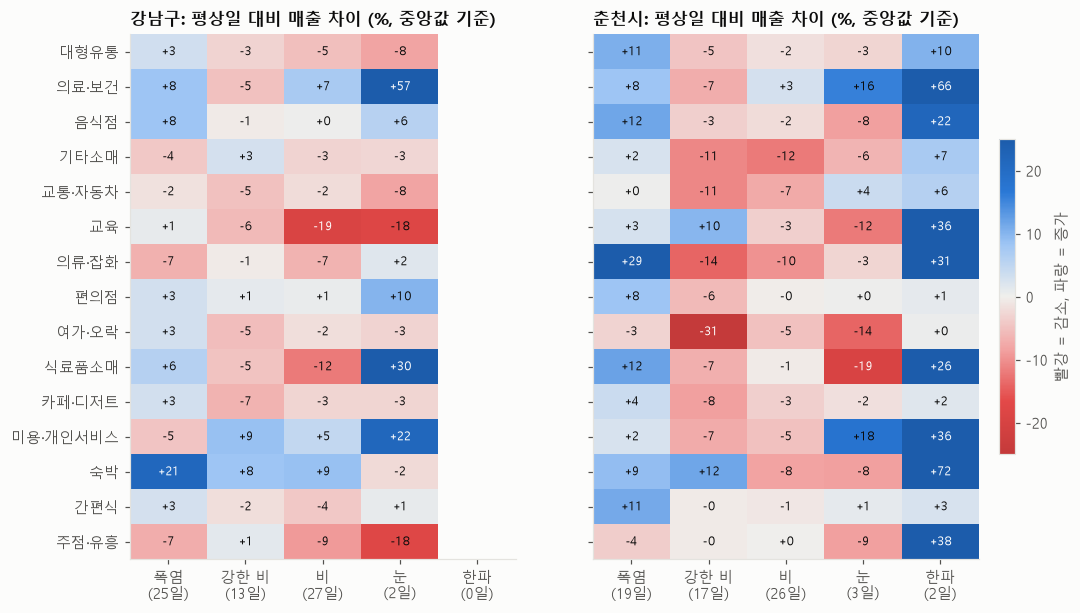

In [17]:
med = dd.groupby(['region', 'industry_group', 'weather_type'], observed=True)['sales_index'].median().unstack('weather_type')
heat = (med.div(med['평상'], axis=0) - 1) * 100   # 평상일 중앙값 대비 차이(%)
types = ['폭염', '강한 비', '비', '눈', '한파']
fig, axes = plt.subplots(1, 2, figsize=(12, 6.2), sharey=True)
for ax, r in zip(axes, REGIONS):
    m = heat.loc[r].reindex(index=order[::-1], columns=[t for t in types if t in heat.columns])
    im = ax.imshow(m.values, cmap=DIV, vmin=-25, vmax=25, aspect='auto')
    ax.set_xticks(range(m.shape[1]), [f'{t}\n({int(days_n.loc[r, t]) if t in days_n.columns and pd.notna(days_n.loc[r, t]) else 0}일)' for t in m.columns])
    ax.set_yticks(range(len(m)), m.index)
    ax.grid(False)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f'{v:+.0f}', ha='center', va='center', fontsize=8, color='white' if abs(v) > 18 else INK)
    ax.set_title(f'{r}: 평상일 대비 매출 차이 (%, 중앙값 기준)', fontsize=11)
cb = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
cb.set_label('빨강 = 감소, 파랑 = 증가', color=INK2)

**단순 비교에서 보이는 방향 (통제 전, 참고용)**
- **비·강한 비**: 두 지역 모두 매출이 평상일보다 낮다. 업종별로는 **춘천 여가·오락(-31%)·의류·잡화(-14%)·교통·자동차·기타소매(-11%)**의 감소가 두드러진다.
- **폭염**: 오히려 평상일보다 **매출이 높게** 나온다. 폭염일이 7월 말~8월 초 휴가 성수기와 겹치기 때문일 가능성이 크다 → 월 단위 통제로는 부족하고, EDA에서 **주(week) 단위 통제**로 다시 본다.
- **눈·한파**: 일수가 2~3일뿐이고 연말(크리스마스·연말 모임)과 겹쳐 해석이 어렵다. 가설 3의 겨울 쪽 근거는 **사건 단위 비교**로 보강해야 한다.
- 업종마다 같은 기상에 대한 반응 방향이 다르게 나타난다 (히트맵의 빨강·파랑이 업종별로 섞임) → **가설 3의 출발점**이다.

## 7. 유동인구·상가 기술통계
### 7-1. 유동인구 (SKT, 월별 일평균)

In [18]:
cols = ['pop_total', 'share_male', 'share_age_20', 'share_age_30', 'share_age_60', 'share_slot_06_11',
        'share_slot_18_23', 'weekend_ratio']
fr = flow_rm.groupby('region')[cols].mean()
fr['pop_total'] = fr['pop_total'] / 1e3
display(fr.rename(columns={'pop_total': '일평균 유동인구(천명)'}).round(3))
print('행정동 단위 분포 (6개월 평균)')
fd = flow_dong.groupby('region')[['pop_total', 'share_age_60', 'weekend_ratio']].describe()
fd.loc[:, (slice(None), ['count', 'mean', 'min', '50%', 'max'])].round(2)

,일평균 유동인구(천명),share_male,share_age_20,share_age_30,share_age_60,share_slot_06_11,share_slot_18_23,weekend_ratio
region,,,,,,,,
강남구,"7,373.15",0.51,0.15,0.19,0.19,0.28,0.26,0.73
춘천시,"1,856.15",0.51,0.14,0.12,0.25,0.28,0.26,0.95


행정동 단위 분포 (6개월 평균)


pop_total                                              share_age_60                     weekend_ratio                    
           count       mean       min        50%          max        count mean  min  50%  max         count mean  min  50%  max
region                                                                                                                          
강남구        22.00 335,143.21 81,611.85 283,753.50 1,240,732.67        22.00 0.21 0.14 0.20 0.29         22.00 0.78 0.56 0.76 1.08
춘천시        25.00  74,246.14  4,596.99  57,848.93   292,482.04        25.00 0.28 0.20 0.25 0.49         25.00 1.01 0.58 1.00 1.46

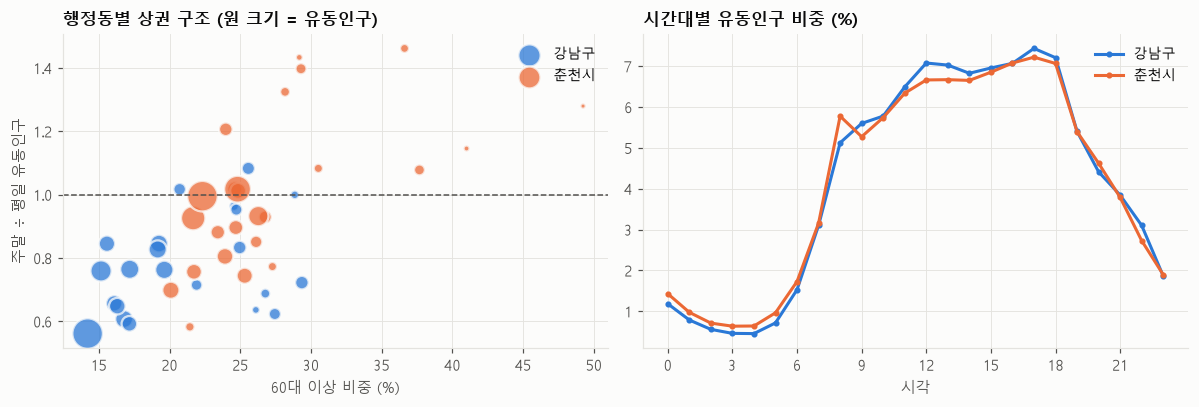

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for r in REGIONS:
    d = flow_dong[flow_dong['region'] == r]
    axes[0].scatter(d['share_age_60'] * 100, d['weekend_ratio'], s=np.clip(d['pop_total'] / d['pop_total'].max() * 400, 12, 400),
                    color=REGION_COLOR[r], alpha=0.75, edgecolor=SURFACE, linewidth=1.5, label=r)
axes[0].axhline(1, color=INK2, lw=1, ls='--')
axes[0].set_xlabel('60대 이상 비중 (%)'); axes[0].set_ylabel('주말 ÷ 평일 유동인구')
axes[0].set_title('행정동별 상권 구조 (원 크기 = 유동인구)', fontsize=11)
axes[0].legend()
hours = load('flow_grid_month')
hcols = [f'TMST_{h:02d}' for h in range(24)]
hp = hours.groupby('region')[hcols].sum()
hp = hp.div(hp.sum(axis=1), axis=0) * 100
for r in REGIONS:
    axes[1].plot(range(24), hp.loc[r], color=REGION_COLOR[r], marker='o', ms=3, label=r)
axes[1].set_xticks(range(0, 24, 3)); axes[1].set_xlabel('시각')
axes[1].set_title('시간대별 유동인구 비중 (%)', fontsize=11)
axes[1].legend()
fig.tight_layout()
del hours

### 7-2. 상가 (점포 수·체인 비중)

In [20]:
sg = store_g.pivot(index='industry_group', columns='region', values=['n_stores', 'chain_share'])
sg[('chain_share', '강남구')] *= 100
sg[('chain_share', '춘천시')] *= 100
print('지역별 분석 대상 점포 수:', store_g.groupby('region')['n_stores'].sum().to_dict())
print('지역별 체인 비중(점포 가중, %):',
      (store_g.assign(c=store_g['n_stores'] * store_g['chain_share']).groupby('region')['c'].sum()
       / store_g.groupby('region')['n_stores'].sum() * 100).round(1).to_dict())
sg.sort_values(('n_stores', '강남구'), ascending=False).round(1)

지역별 분석 대상 점포 수: {'강남구': 36380, '춘천시': 14926}
지역별 체인 비중(점포 가중, %): {'강남구': 14.0, '춘천시': 10.4}


n_stores          chain_share      
region              강남구      춘천시         강남구   춘천시
industry_group                                    
음식점            7,256.00 3,333.00       20.20 11.20
교육             5,164.00 1,218.00        4.30  3.70
의료·보건          3,825.00   579.00        1.50  1.70
미용·개인서비스       3,629.00 1,537.00        9.00  6.30
의류·잡화          3,499.00 1,033.00       13.90 13.50
기타소매           3,122.00 1,362.00       11.70 10.40
카페·디저트         2,671.00 1,128.00       29.30 15.00
간편식            1,474.00   836.00       35.10 28.70
여가·오락          1,384.00   688.00       11.50  8.00
주점·유흥          1,227.00   610.00        8.40  7.20
식료품소매            863.00   490.00       13.00  5.70
편의점              803.00   373.00       45.80 37.80
숙박               537.00   818.00        2.40  0.50
교통·자동차           474.00   514.00       13.10  5.40
대형유통             452.00   407.00       16.80  9.60

- 강남은 유동인구가 춘천의 약 4배이고 **주말이 평일의 73%**인 평일 상권, 춘천은 주말·평일이 비슷하고 **60대 이상 비중이 25%**로 높다.
- 춘천 안에서도 행정동별로 고령 비중(20~49%)과 주말 비율(0.58~1.46)이 크게 달라, 같은 지역 안에서도 상권 성격이 다양하다.
- 상가: 춘천은 체인 비중이 더 낮다 (10.4% vs 14.0%). 특히 카페·디저트(15% vs 29%), 숙박(0.5%)처럼 **독립 점포가 대부분인 업종**은 날씨 충격을 흡수할 여력이 적을 수 있다.

## 8. 정리 — EDA로 넘길 질문

| 기술통계에서 확인한 것 | EDA에서 볼 것 |
|---|---|
| 매출 변동의 대부분은 요일·연휴 → 날씨는 작은 신호 | 주 고정효과 등 **달력 통제 후** 기상 효과가 남는가 |
| 폭염일 매출이 오히려 높음 (휴가철과 겹침) | 성수기 효과를 걷어내면 폭염 효과는 어떻게 되는가 |
| 비·강한 비 날 매출 감소, 춘천이 더 큼 | 강수량 구간·시간대·고객 출신별로 감소가 어디서 오는가 |
| 강남 평일 상권 vs 춘천 주말·방문객 상권 | 평일 비 vs 주말 비, 현지 고객 vs 외지 고객의 반응 차이 |
| 업종별 기상 반응 방향이 다름 | **가설 3**: 기상 유형 × 업종 반응 지도 (여름 vs 겨울 반전 업종이 있는가) |
| 점포당 월매출이 업종·지역별로 최대 550배 차이 | **가설 1·2**: 같은 피해액이 규모별로 다른 타격(피해율) — 피해 예측 후 산출 |
| 눈·한파 표본 2~3일 | 사건 단위 비교(전후 일주일)로 보완, 한계 명시 |